## 0. 데이터 불러오기
Kaggle의 EV Battery Failure Prediction Dataset(200K) 원본을 불러온다.
- 원본: 200,000행 × 70열, 타겟 `battery_failure` (불량률 약 10%)
- 이후 전처리를 거쳐 분석용 데이터를 생성한다.

In [1]:
a = 1
a

1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 한글 폰트 (Windows: 'Malgun Gothic' / Mac: 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 원본 데이터 로드
df_raw = pd.read_csv("../data/ev_battery_failure_dataset.csv")
TARGET = 'battery_failure'
print(f"원본 데이터: {df_raw.shape}")   # (200000, 70)

원본 데이터: (200000, 70)


## 1. 데이터 전처리
원본에서 두 가지 필터링을 적용해 분석용 데이터를 만든다.
1. **범주형 결측 행 제거**: vehicle_brand / model / type 중 하나라도 결측인 행 삭제
2. **국내 서비스센터 미보유 브랜드 제거**: Rivian, Lucid, Tata, Mahindra, MG
   (국내 A/S망이 없어 분석 대상에서 제외)

결측치 보정·이상치·스케일링은 데이터 누수 방지를 위해 **학습/테스트 분리 이후**(모델링 단계)에 수행한다.

### 재현 코드

In [6]:
# ── (1) vehicle_brand / model / type 중 하나라도 결측인 행 제거 ──
cat_null_cols = ['vehicle_brand', 'vehicle_model', 'vehicle_type']
mask_null = df_raw[cat_null_cols].isnull().any(axis=1)
print(f"[결측 제거] 대상 {mask_null.sum():,}행")

df = df_raw[~mask_null].copy()
print(f"  → 제거 후 {len(df):,}행")

# ── (2) 국내 서비스센터 미보유 브랜드 제거 ──
no_service_brands = ['Rivian', 'Lucid', 'Tata', 'Mahindra', 'MG']
before = len(df)
df = df[~df['vehicle_brand'].isin(no_service_brands)]
print(f"[브랜드 제거] {no_service_brands}")
print(f"  → {before:,}행 → {len(df):,}행 ({before - len(df):,}행 제거)")

# ── (3) 결과 확인 ──
print(f"\n최종 분석 데이터: {df.shape}")   # (154036, 70)
print(f"남은 브랜드 {df['vehicle_brand'].nunique()}개:")
print(df['vehicle_brand'].value_counts())

# ── (4) 저장 (선택 — 이후 이 파일을 바로 불러와 쓸 수도 있음) ──
df.to_csv("../data/df_cleaned_nocenter.csv", index=False)

[결측 제거] 대상 20,408행
  → 제거 후 179,592행
[브랜드 제거] ['Rivian', 'Lucid', 'Tata', 'Mahindra', 'MG']
  → 179,592행 → 154,036행 (25,556행 제거)

최종 분석 데이터: (154036, 70)
남은 브랜드 15개:
vehicle_brand
Tesla         20280
BYD           18737
Volkswagen    13597
Hyundai       12024
GM            10296
Ford          10130
Kia           10005
Mercedes       8535
Nissan         8473
BMW            8398
Toyota         8375
Audi           6758
Renault        6717
Volvo          6703
Honda          5008
Name: count, dtype: int64


## 2. 데이터 분석 (EDA)
70개 열 중 예측에 쓸 변수를 규칙 기반으로 선별한다.
필터 방식(filter method): 임계값 3개만 근거로 제시하면 누가 돌려도 같은 결과가 나온다.
- CORR_TH=0.25 (숫자형 타겟 상관), MC_TH=0.85 (다중공선성), CRAMER_TH=0.10 (범주형 신호)

### 2-1 선택 규칙 정의 + 후보 분리

In [7]:
# ── 선택 규칙 (임계값 = 근거로 명시) ──
CORR_TH   = 0.25    # 숫자형: 타겟과 |상관계수| 최소 기준
MC_TH     = 0.85    # 다중공선성: 이 이상 겹치면 중복
CRAMER_TH = 0.10    # 범주형: Cramér's V 최소 기준

# STEP0: 식별자 제외
id_like = ['vehicle_id', 'battery_serial', 'vehicle_model']
feat_df = df.drop(columns=id_like + [TARGET])
num_cols = feat_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = feat_df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"[STEP0] 70개 → 식별자 {len(id_like)} 제외 → 숫자형 {len(num_cols)} / 범주형 {len(cat_cols)}")

[STEP0] 70개 → 식별자 3 제외 → 숫자형 59 / 범주형 7


##### STEP1&2: 숫자형 상관 → 다중공선성 제거

[STEP1] |corr|>=0.25 통과: 25개
[STEP2] 다중공선성 제거 후: 16개
['capacity_loss_percent', 'charge_efficiency', 'cycle_count', 'voltage_imbalance', 'charging_quality_score', 'thermal_runaway_risk', 'internal_resistance', 'daily_distance', 'charging_cycles_last_month', 'remaining_capacity', 'battery_stress_index', 'cooling_system_health', 'fast_charge_ratio', 'BMS_warning_count', 'vehicle_age_years', 'predicted_remaining_life_cycles']


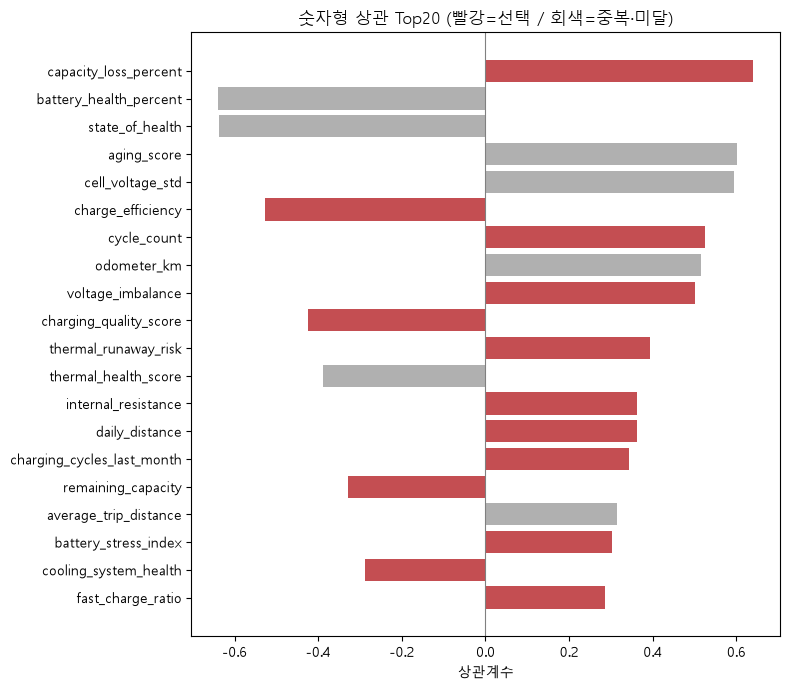

In [8]:
# STEP1: 타겟 상관 필터
corr_t = df[num_cols + [TARGET]].corr()[TARGET].drop(TARGET)
num_cand = corr_t[corr_t.abs() >= CORR_TH].abs().sort_values(ascending=False).index.tolist()
print(f"[STEP1] |corr|>={CORR_TH} 통과: {len(num_cand)}개")

# STEP2: 다중공선성 제거 (타겟상관 높은 순, 이미 뽑힌 것과 |r|>=MC_TH면 버림)
cmat = df[num_cand].corr().abs()
num_selected = []
for c in num_cand:
    if all(cmat.loc[c, k] < MC_TH for k in num_selected):
        num_selected.append(c)
print(f"[STEP2] 다중공선성 제거 후: {len(num_selected)}개")
print(num_selected)

# 시각화: 상관 Top20 (선택=빨강 / 미선택=회색)
top = corr_t.reindex(corr_t.abs().sort_values(ascending=False).index).head(20)
colors = ['#C44E52' if c in num_selected else '#B0B0B0' for c in top.index]
plt.figure(figsize=(8, 7))
plt.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
plt.axvline(0, color='gray', lw=0.8)
plt.title('숫자형 상관 Top20 (빨강=선택 / 회색=중복·미달)')
plt.xlabel('상관계수'); plt.tight_layout(); plt.show()

##### STEP3: 범주형 Cramér's V

[STEP3] Cramér's V>=0.1 통과: ['fleet_or_private', 'battery_chemistry', 'vehicle_brand']
fleet_or_private        0.342
battery_chemistry       0.198
vehicle_brand           0.133
vehicle_type            0.096
battery_manufacturer    0.006
terrain_type            0.003
drive_type              0.002


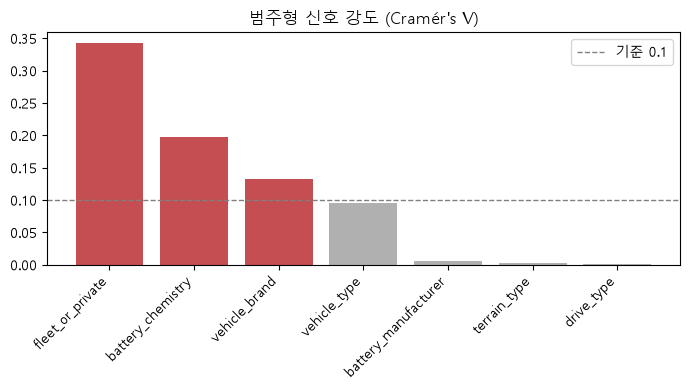

In [9]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum(); r, k = ct.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

cv = pd.Series({c: cramers_v(df[c], df[TARGET]) for c in cat_cols}).sort_values(ascending=False)
cat_pass = cv[cv >= CRAMER_TH].index.tolist()
print(f"[STEP3] Cramér's V>={CRAMER_TH} 통과: {cat_pass}")
print(cv.round(3).to_string())

plt.figure(figsize=(7, 4))
colors = ['#C44E52' if c in cat_pass else '#B0B0B0' for c in cv.index]
plt.bar(cv.index, cv.values, color=colors)
plt.axhline(CRAMER_TH, color='gray', ls='--', lw=1, label=f'기준 {CRAMER_TH}')
plt.title("범주형 신호 강도 (Cramér's V)")
plt.xticks(rotation=45, ha='right'); plt.legend(); plt.tight_layout(); plt.show()

### 2-2. 선택 근거 검증 (4중 검증)

In [10]:
# MI (비선형 신호 확인)

from sklearn.feature_selection import mutual_info_classif

tmp = df[num_cols + [TARGET]].dropna()
mi = pd.Series(mutual_info_classif(tmp[num_cols], tmp[TARGET], random_state=42),
               index=num_cols).sort_values(ascending=False)
compare = pd.DataFrame({'MI': mi, '|corr|': corr_t.abs()}).sort_values('MI', ascending=False)
print(compare.head(15).round(3).to_string())

                                    MI  |corr|
battery_health_percent           0.180   0.639
capacity_loss_percent            0.180   0.640
state_of_health                  0.177   0.637
cell_voltage_std                 0.171   0.593
aging_score                      0.164   0.601
predicted_remaining_life_cycles  0.145   0.255
voltage_imbalance                0.141   0.500
charge_efficiency                0.128   0.527
cycle_count                      0.118   0.525
odometer_km                      0.116   0.515
thermal_runaway_risk             0.114   0.394
internal_resistance              0.105   0.363
thermal_health_score             0.102   0.390
charging_quality_score           0.099   0.425
daily_distance                   0.064   0.362


In [11]:
# VIF (다중공선성 정밀 검증, 상수항 필수)

# pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(df[num_selected].dropna())   # 상수항 추가가 핵심 (없으면 VIF 폭발)
vif = pd.Series([variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
                index=X_vif.columns).drop('const').sort_values(ascending=False)
print(vif.round(2).to_string())   # 전부 10 미만이면 통제됨

capacity_loss_percent              9.77
cycle_count                        6.04
thermal_runaway_risk               4.42
vehicle_age_years                  4.26
daily_distance                     4.06
cooling_system_health              3.82
charging_cycles_last_month         3.34
charging_quality_score             3.31
charge_efficiency                  3.14
fast_charge_ratio                  2.68
predicted_remaining_life_cycles    2.53
voltage_imbalance                  2.35
remaining_capacity                 2.05
internal_resistance                1.81
battery_stress_index               1.58
BMS_warning_count                  1.23


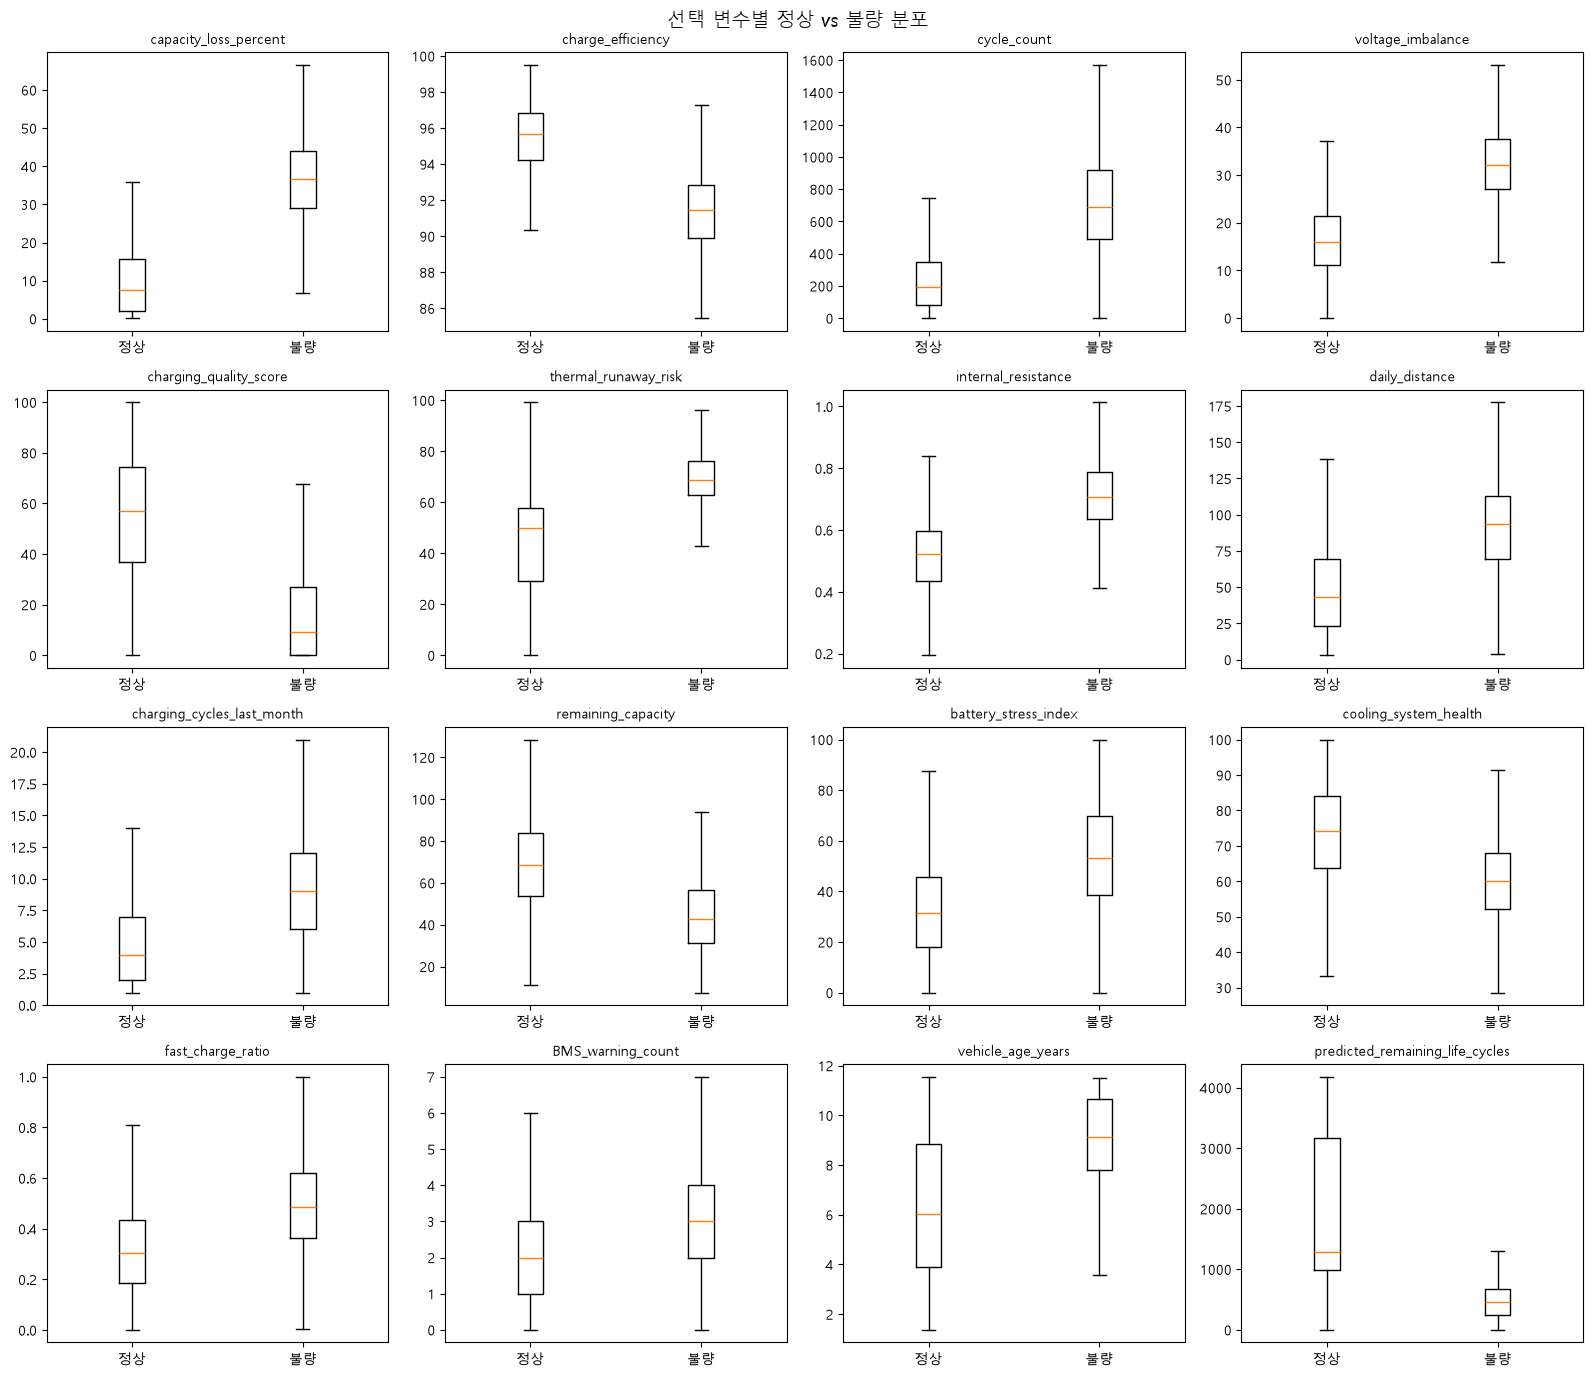

In [13]:
# 클래스 분리 박스플롯

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
for ax, col in zip(axes.ravel(), num_selected):
    data = [df[df[TARGET]==0][col].dropna(), df[df[TARGET]==1][col].dropna()]
    ax.boxplot(data, tick_labels=['정상', '불량'], showfliers=False)
    ax.set_title(col, fontsize=10)
plt.suptitle('선택 변수별 정상 vs 불량 분포', fontsize=14)
plt.tight_layout(); plt.show()

In [14]:
# 선택 변수 결측률

miss = (df[num_selected + cat_pass].isna().mean() * 100).sort_values(ascending=False)
print(miss[miss > 0].round(2).to_string())

fast_charge_ratio                  4.96
capacity_loss_percent              4.79
cooling_system_health              4.68
charge_efficiency                  4.66
BMS_warning_count                  4.56
predicted_remaining_life_cycles    4.48
fleet_or_private                   4.43
daily_distance                     4.25
charging_cycles_last_month         3.97
internal_resistance                3.97
cycle_count                        3.87
vehicle_age_years                  3.84
battery_stress_index               3.67
voltage_imbalance                  3.62
battery_chemistry                  3.61
thermal_runaway_risk               3.57
charging_quality_score             3.56
remaining_capacity                 3.07


### 2-3. 범주형 변수 제외 근거
단변량에서 강해 보인 범주형(fleet, chemistry, brand)이 숫자형 위에 '실제 예측력'을 더하는지 검증.
핵심 개념: 주변 연관성(Cramér's V) ≠ 증분 기여(모델 AUC 변화)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, average_precision_score
import xgboost as xgb   # 검증용 (본 모델은 LightGBM)

def eval_features(cat_list, tag):
    X = df[num_selected + cat_list]; y = df[TARGET]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    trans = [('num', SimpleImputer(strategy='median'), num_selected)]
    if cat_list:
        trans.append(('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                                       ('o', OneHotEncoder(handle_unknown='ignore'))]), cat_list))
    pre = ColumnTransformer(trans)
    spw = (y_tr == 0).sum() / (y_tr == 1).sum()
    m = Pipeline([('pre', pre), ('clf', xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, scale_pos_weight=spw, eval_metric='logloss', random_state=42))])
    m.fit(X_tr, y_tr)
    p = m.predict_proba(X_te)[:, 1]
    print(f"  {tag:<28} AUC={roc_auc_score(y_te,p):.4f}  PR-AUC={average_precision_score(y_te,p):.4f}")

# 검증 A: 브랜드가 chemistry의 대리변수인지
print("=== 검증 A: vehicle_brand 증분 ===")
eval_features(['fleet_or_private', 'battery_chemistry'], "chem+fleet")
eval_features(['fleet_or_private', 'battery_chemistry', 'vehicle_brand'], "chem+fleet+brand")

# 검증 B: 범주형이 숫자형 위에 필요한지
print("\n=== 검증 B: 범주형 증분 ===")
eval_features([], "숫자형만")
eval_features(['fleet_or_private', 'battery_chemistry'], "+ fleet+chem")
# 결과: 둘 다 ΔAUC≈0 → 범주형 전량 제외

=== 검증 A: vehicle_brand 증분 ===
  chem+fleet                   AUC=0.9862  PR-AUC=0.9030
  chem+fleet+brand             AUC=0.9862  PR-AUC=0.9029

=== 검증 B: 범주형 증분 ===
  숫자형만                         AUC=0.9861  PR-AUC=0.9018
  + fleet+chem                 AUC=0.9862  PR-AUC=0.9030


#### EDA 변수 선택 종합 결론
- 파이프라인: 70개 → 식별자 제외 → 상관(|corr|≥0.25) → 다중공선성(|r|≥0.85) → 숫자형 16개
- 4중 검증: 상관·MI·VIF(전부<10)·Cramér's V 모두 일치
- 범주형 제외: fleet·chemistry·brand는 단변량 최강 신호이나 숫자형 대비 증분 AUC≈0
  (효과가 측정값에 매개됨) → 모델 입력에서 제외
- 원칙: 주변 연관성이 강해도 증분 기여가 없으면 제외
- 최종: 숫자형 16개 (모델링에서 predicted_remaining_life_cycles 추가 제외 → 15개)

# 2. 데이터 분석(EDA) — 변수 선택 종합 결론

## 2.1 분석 데이터
- 파일: `df_cleaned_nocenter.csv` (154,036행 × 70열)
- 원본 200K에서 ① 범주형(brand/model/type) 결측 행, ② 국내 서비스센터 미보유 브랜드 5종(Rivian, Lucid, Tata, Mahindra, MG)을 제거한 상태
- 타겟: `battery_failure` (불량률 약 10.3%, 불균형 데이터)

## 2.2 변수 선택 파이프라인 (70 → 16)
필터 방식(filter method)으로 규칙 기반 선별. 임계값 3개만으로 재현 가능.

| 단계 | 규칙 | 결과 |
|---|---|---|
| STEP0 | 식별자 제외 (vehicle_id, battery_serial, vehicle_model) | 숫자형 59 / 범주형 7 |
| STEP1 | 숫자형: 타겟과 \|corr\| ≥ 0.25 | 25개 통과 |
| STEP2 | 다중공선성 \|r\| ≥ 0.85 중복 제거 | 숫자형 16개 |
| STEP3 | 범주형: Cramér's V ≥ 0.10 | 범주형 3개(1차) |
| 추가검증 | 증분 기여 테스트 | 범주형 전량 제외 |
| **최종** | | **숫자형 16개** |

## 2.3 선택 근거 4중 검증
| 지표 | 목적 | 결과 |
|---|---|---|
| 상관계수 | 1차 선별 | 선택 변수 전부 상관 상위권, 배터리 열화 물리와 방향 일치 |
| 상호정보량(MI) | 비선형 신호 확인 | MI 상위 = 상관 상위와 일치 → 놓친 변수 없음 |
| VIF | 다중공선성 정밀 검증 | 상수항 포함 시 전부 10 미만(최대 capacity_loss_percent 9.77) |
| Cramér's V | 범주형 신호 강도 | fleet(0.34) > chemistry(0.20) > brand(0.13)만 1차 통과 |

## 2.4 추가 검증 — 브랜드 및 범주형 제외 근거
단변량에서 강해 보인 범주형이 **실제 예측력(증분 AUC)을 더하는지** 모델로 검증.

**검증 A — vehicle_brand**
- chem+fleet 대비 브랜드 추가 효과: **ΔAUC = +0.00005 (≈ 0)**
- 브랜드별 불량률 차이는 chemistry로 설명됨(BYD=LFP 2.7%, Tesla=NCA 13.8%) → chemistry의 대리변수
- 원핫 시 15컬럼으로 차원만 증가, 신규 브랜드 일반화 불가 → **제외**

**검증 B — fleet_or_private, battery_chemistry**
- 숫자형 16개 대비 범주형 추가 효과: **ΔAUC = +0.0000, ΔPR-AUC = +0.0001 (≈ 0)**
- 특성 중요도 Top10 전부 숫자형(범주형 원핫 미포함)
- 원인(chemistry·fleet)의 효과가 측정값(capacity_loss, cycle_count 등)에 매개(mediation)되어 이미 반영됨 → **모델 입력에서 제외**

> **원칙**: 주변 연관성(Cramér's V)이 강해도 증분 기여(모델 ΔAUC)가 없으면 제외한다.
> fleet·chemistry는 단변량 EDA에서 가장 강한 신호이므로 **해석·발표용 EDA에는 유지**하되, **최종 모델 입력은 숫자형 16개**로 확정.

## 2.5 최종 선택 변수 (16개)
['capacity_loss_percent', 'charge_efficiency', 'cycle_count', 'voltage_imbalance',
'charging_quality_score', 'thermal_runaway_risk', 'internal_resistance', 'daily_distance',
'charging_cycles_last_month', 'remaining_capacity', 'battery_stress_index', 'cooling_system_health',
'fast_charge_ratio', 'BMS_warning_count', 'vehicle_age_years', 'predicted_remaining_life_cycles']


특성 중요도(참고): capacity_loss_percent(0.49)가 압도적, 이어 voltage_imbalance(0.09), predicted_remaining_life_cycles(0.09), charging_quality_score(0.05) 순.

## 2.6 모델링 단계로 이월할 관찰 사항
| 변수 | 관찰 | 조치 |
|---|---|---|
| `predicted_remaining_life_cycles` | 이름이 '예측값'이고 MI가 상관보다 유독 높음(누수 의심). 중요도 3위지만 제거해도 AUC 불변(중복) | 포함/제외 성능 비교로 최종 판정 |
| `BMS_warning_count` | 박스플롯 분리력 약함(중앙값 2 vs 3), VIF 최저(1.23) | 특성 중요도 낮으면 제거 |

---
**결론**: EDA 결과, 최종 입력 변수는 숫자형 16개로 확정한다. 범주형은 예측 기여가 없어 모델에서 제외하며, 두 변수(`predicted_remaining_life_cycles`, `BMS_warning_count`)는 모델링 단계에서 최종 검토한다.

## 3. 모델링
- 모델: LightGBM (팀원 XGBoost와 비교)
- 변수: 15개 (predicted_remaining_life_cycles는 누수 의심으로 제외)
- 분할: Train/Val/Test = 6:2:2 (stratify)
- 불균형(불량 약 10%) 처리: class_weight vs 언더샘플링 2가지 비교

### 분리(6:2:2) + 결측 보정

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, confusion_matrix)
from imblearn.under_sampling import RandomUnderSampler
import lightgbm as lgb

# 최종 변수 15개
features = ['capacity_loss_percent', 'charge_efficiency', 'cycle_count', 'voltage_imbalance',
    'charging_quality_score', 'thermal_runaway_risk', 'internal_resistance', 'daily_distance',
    'charging_cycles_last_month', 'remaining_capacity', 'battery_stress_index',
    'cooling_system_health', 'fast_charge_ratio', 'BMS_warning_count', 'vehicle_age_years']

X = df[features]; y = df[TARGET]
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)
print(f"Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape}")

# 결측 보정 (train 중앙값을 val/test에 적용 = 누수 방지)
imputer = SimpleImputer(strategy='median').fit(X_train)
X_train = pd.DataFrame(imputer.transform(X_train), columns=features, index=X_train.index)
X_val   = pd.DataFrame(imputer.transform(X_val),   columns=features, index=X_val.index)
X_test  = pd.DataFrame(imputer.transform(X_test),  columns=features, index=X_test.index)
# 스케일링 생략: LightGBM은 트리 기반이라 불필요

Train (92421, 15) | Val (30807, 15) | Test (30808, 15)


### 불균형 2방식 비교 + 혼동행렬

In [17]:
def fit_eval(X_fit, y_fit, tag, class_weight=None):
    model = lgb.LGBMClassifier(
        n_estimators=1000, learning_rate=0.05, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8,
        class_weight=class_weight, random_state=42, verbose=-1)
    model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], eval_metric='auc',
              callbacks=[lgb.early_stopping(50, verbose=False)])
    prob = model.predict_proba(X_test)[:, 1]; pred = model.predict(X_test)
    auc = roc_auc_score(y_test, prob); ap = average_precision_score(y_test, prob)

    print(f"\n{'='*52}\n[{tag}] best_iter={model.best_iteration_}  "
          f"AUC={auc:.4f}  PR-AUC={ap:.4f}\n{'='*52}")
    print(classification_report(y_test, pred, target_names=['정상', '불량'], digits=3))

    # 혼동행렬: 실제 개수(정탐/오탐/놓침)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print("[ 혼동행렬 (행=실제, 열=예측) ]")
    print(f"              예측:정상   예측:불량")
    print(f"  실제:정상 {tn:>10,} {fp:>10,}")
    print(f"  실제:불량 {fn:>10,} {tp:>10,}")
    print(f"  ✓ 불량 정탐(TP): {tp:,} / ✗ 불량 놓침(FN): {fn:,} (가장 위험)")
    print(f"  ✗ 정상 오탐(FP): {fp:,} / ✓ 정상 정탐(TN): {tn:,}")
    return model

# 방식1: class_weight
model_cw = fit_eval(X_train, y_train, "class_weight='balanced'", class_weight='balanced')

# 방식2: 언더샘플링 (train만 2:1)
rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)
print(f"\n언더샘플링 후 train: {dict(pd.Series(y_res).value_counts())}")
model_us = fit_eval(X_res, y_res, "undersampling (2:1)")

c:\dev\03.python\04.batteryproject\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



[class_weight='balanced'] best_iter=222  AUC=0.9858  PR-AUC=0.8998
              precision    recall  f1-score   support

          정상      0.993     0.941     0.966     27649
          불량      0.646     0.945     0.767      3159

    accuracy                          0.941     30808
   macro avg      0.820     0.943     0.867     30808
weighted avg      0.958     0.941     0.946     30808

[ 혼동행렬 (행=실제, 열=예측) ]
              예측:정상   예측:불량
  실제:정상     26,012      1,637
  실제:불량        174      2,985
  ✓ 불량 정탐(TP): 2,985 / ✗ 불량 놓침(FN): 174 (가장 위험)
  ✗ 정상 오탐(FP): 1,637 / ✓ 정상 정탐(TN): 26,012

언더샘플링 후 train: {0: np.int64(18952), 1: np.int64(9476)}


c:\dev\03.python\04.batteryproject\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)



[undersampling (2:1)] best_iter=190  AUC=0.9853  PR-AUC=0.8954
              precision    recall  f1-score   support

          정상      0.990     0.951     0.970     27649
          불량      0.683     0.918     0.783      3159

    accuracy                          0.948     30808
   macro avg      0.837     0.935     0.877     30808
weighted avg      0.959     0.948     0.951     30808

[ 혼동행렬 (행=실제, 열=예측) ]
              예측:정상   예측:불량
  실제:정상     26,302      1,347
  실제:불량        258      2,901
  ✓ 불량 정탐(TP): 2,901 / ✗ 불량 놓침(FN): 258 (가장 위험)
  ✗ 정상 오탐(FP): 1,347 / ✓ 정상 정탐(TN): 26,302


### 특성 중요도

In [18]:
imp = pd.Series(model_cw.feature_importances_, index=features).sort_values(ascending=False)
print(imp.to_string())   # BMS_warning_count가 하위권이면 제거 후보

charging_quality_score        759
battery_stress_index          665
voltage_imbalance             642
thermal_runaway_risk          600
cooling_system_health         588
vehicle_age_years             494
BMS_warning_count             486
capacity_loss_percent         472
internal_resistance           413
fast_charge_ratio             387
remaining_capacity            286
charge_efficiency             285
cycle_count                   244
daily_distance                230
charging_cycles_last_month    109


## 4. 모델 평가 및 비교
두 불균형 처리 방식(class_weight vs 언더샘플링)을 동일 Test셋에서 비교해 최종 모델을 선택한다.
평가 지표: AUC, PR-AUC(불균형 민감), 그리고 불량 클래스의 recall/precision/f1 및 실제 오탐·놓침 개수.

In [19]:
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix,
                             f1_score, precision_score, recall_score)

def collect_metrics(model, name):
    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return {
        '모델': name,
        'AUC': roc_auc_score(y_test, prob),
        'PR-AUC': average_precision_score(y_test, prob),
        '불량_recall': recall_score(y_test, pred),
        '불량_precision': precision_score(y_test, pred),
        '불량_f1': f1_score(y_test, pred),
        'FN(놓침)': fn,
        'FP(오탐)': fp,
    }

compare_df = pd.DataFrame([
    collect_metrics(model_cw, "class_weight"),
    collect_metrics(model_us, "undersampling"),
])
print(compare_df.round(4).to_string(index=False))

           모델    AUC  PR-AUC  불량_recall  불량_precision  불량_f1  FN(놓침)  FP(오탐)
 class_weight 0.9858  0.8998     0.9449        0.6458 0.7673     174    1637
undersampling 0.9853  0.8954     0.9183        0.6829 0.7833     258    1347


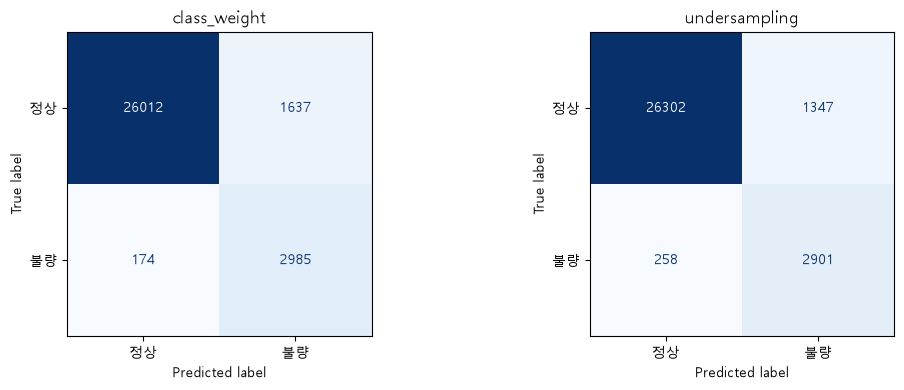

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (model, name) in zip(axes, [(model_cw, "class_weight"), (model_us, "undersampling")]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, model.predict(X_test), display_labels=['정상', '불량'],
        cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

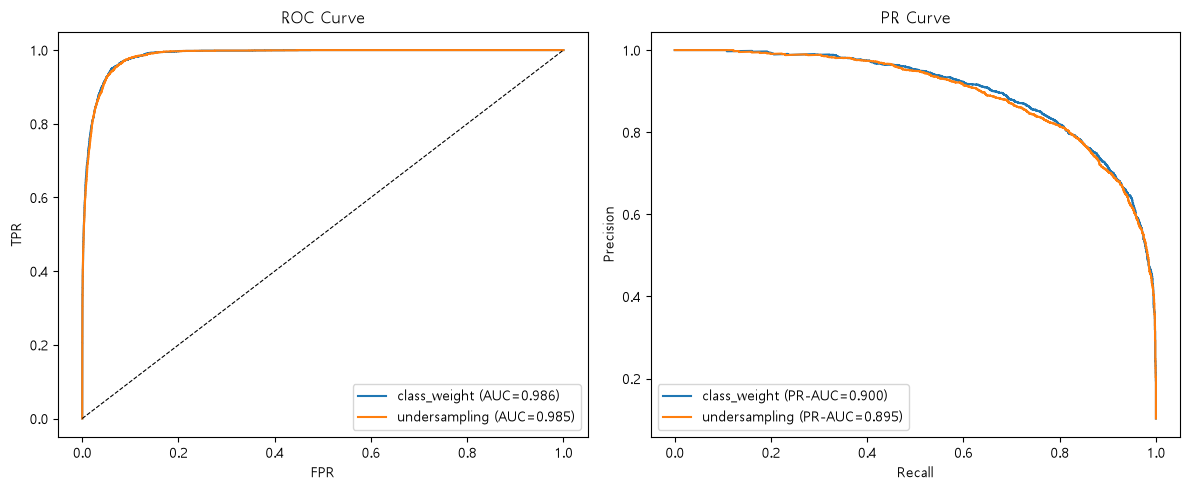

In [21]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for model, name in [(model_cw, "class_weight"), (model_us, "undersampling")]:
    prob = model.predict_proba(X_test)[:, 1]
    # ROC
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax1.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
    # PR
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ax2.plot(rec, prec, label=f"{name} (PR-AUC={average_precision_score(y_test, prob):.3f})")

ax1.plot([0, 1], [0, 1], 'k--', lw=0.8); ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Curve'); ax1.legend()
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision'); ax2.set_title('PR Curve'); ax2.legend()
plt.tight_layout(); plt.show()

### 평가 결론
- 두 방식 모두 AUC ≈ 0.986으로 판별력은 동등.
- 차이는 recall/precision 트레이드오프:
  - class_weight: 불량 recall 0.945 (놓침 174개) — 불량을 더 잘 잡음
  - undersampling: 불량 precision 0.683 (오탐 감소) — 오경보가 적음, f1 소폭 우위
- 배터리 불량 예측은 '놓침(FN)'의 비용이 크므로 **class_weight 방식을 최종 모델로 선택**.
  (오탐은 추가 점검 비용이나, 놓침은 실제 고장으로 이어짐)

### 4-2. 임계값(threshold) 조정
기본 임계값 0.5는 f1 기준이지만, 배터리 불량 예측의 목적은 '놓침(FN) 최소화'다.
임계값을 낮추면 recall이 오르고 놓침이 줄어드는 대신 오탐(FP)이 늘어난다.
운영 목적(불량을 놓치지 않기)에 맞는 임계값을 선택한다.

In [22]:
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

# 최종 모델(model_cw)의 예측 확률
prob = model_cw.predict_proba(X_test)[:, 1]

print(f"{'임계값':>6} {'recall':>8} {'precision':>10} {'f1':>7} {'FN(놓침)':>9} {'FP(오탐)':>9}")
for thr in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]:
    pred = (prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"{thr:>6} {recall_score(y_test,pred):>8.3f} {precision_score(y_test,pred):>10.3f} "
          f"{f1_score(y_test,pred):>7.3f} {fn:>9,} {fp:>9,}")

   임계값   recall  precision      f1    FN(놓침)    FP(오탐)
   0.5    0.945      0.646   0.767       174     1,637
   0.4    0.957      0.610   0.745       136     1,932
   0.3    0.968      0.572   0.719       100     2,293
  0.25    0.973      0.549   0.702        84     2,521
   0.2    0.978      0.526   0.684        71     2,783
  0.15    0.982      0.499   0.662        58     3,108
   0.1    0.988      0.466   0.633        38     3,576


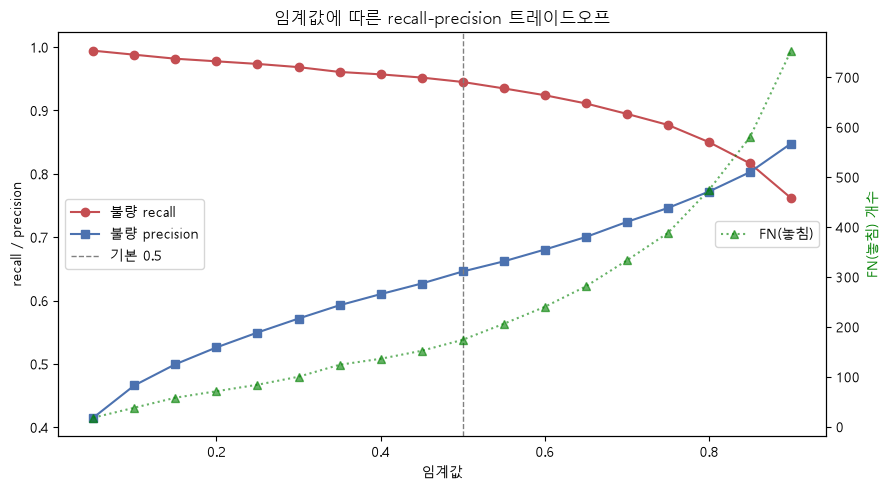

In [23]:
import matplotlib.pyplot as plt

thresholds = np.arange(0.05, 0.95, 0.05)
recalls, precisions, fns = [], [], []
for thr in thresholds:
    pred = (prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    recalls.append(recall_score(y_test, pred))
    precisions.append(precision_score(y_test, pred))
    fns.append(fn)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(thresholds, recalls, 'o-', color='#C44E52', label='불량 recall')
ax1.plot(thresholds, precisions, 's-', color='#4C72B0', label='불량 precision')
ax1.axvline(0.5, color='gray', ls='--', lw=1, label='기본 0.5')
ax1.set_xlabel('임계값'); ax1.set_ylabel('recall / precision'); ax1.legend(loc='center left')
ax1.set_title('임계값에 따른 recall-precision 트레이드오프')

ax2 = ax1.twinx()   # 놓침 개수 보조축
ax2.plot(thresholds, fns, '^:', color='green', alpha=0.6, label='FN(놓침)')
ax2.set_ylabel('FN(놓침) 개수', color='green')
ax2.legend(loc='center right')
plt.tight_layout(); plt.show()

In [24]:
# 목적(놓침 최소화)에 따라 임계값 선택 — 예: 0.2 (놓침 절반 이하로 감소)
FINAL_THRESHOLD = 0.2

pred_final = (prob >= FINAL_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred_final).ravel()
print(f"[최종 임계값 {FINAL_THRESHOLD}] LightGBM (class_weight)")
print(f"  불량 recall: {recall_score(y_test, pred_final):.3f}  "
      f"precision: {precision_score(y_test, pred_final):.3f}  "
      f"f1: {f1_score(y_test, pred_final):.3f}")
print(f"  불량 놓침(FN): {fn:,}개  /  정상 오탐(FP): {fp:,}개")

[최종 임계값 0.2] LightGBM (class_weight)
  불량 recall: 0.978  precision: 0.526  f1: 0.684
  불량 놓침(FN): 71개  /  정상 오탐(FP): 2,783개


### 임계값 결론
- 기본 0.5 → 0.2로 조정 시 불량 놓침이 174개 → 71개로 절반 이하 감소 (recall 0.945 → 0.978).
- 대가로 오탐은 1,637개 → 2,783개로 증가하나, 배터리 안전 관점에서 '놓침 감소'가 우선.
- 참고: f1 최대 임계값은 0.83(f1 0.81)이나 recall을 낮추는 방향이라 목적과 불일치.
  → f1 최적이 아니라 '운영 목적에 맞는 임계값'을 선택하는 것이 핵심.

# 5. 최종 모델 정리 및 버전 요약

In [25]:
# ── 최종 모델 정리 ──
import joblib
from datetime import datetime

FINAL_MODEL = model_cw
FINAL_FEATURES = features  # 최종 학습에 사용한 변수 15개 (위 3번 항목과 동일)
MODEL_VERSION = "v1_notebook_" + datetime.now().strftime("%Y%m%d")

pred_summary = (prob >= FINAL_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred_summary).ravel()

summary = {
    "model": "LightGBM (class_weight='balanced')",
    "n_features": len(FINAL_FEATURES),
    "threshold": FINAL_THRESHOLD,
    "AUC": roc_auc_score(y_test, prob),
    "PR-AUC": average_precision_score(y_test, prob),
    "recall(불량)": recall_score(y_test, pred_summary),
    "precision(불량)": precision_score(y_test, pred_summary),
    "f1(불량)": f1_score(y_test, pred_summary),
    "FN(놓침)": int(fn),
    "FP(오탐)": int(fp),
}

print("=" * 60)
print(f"[최종 모델 요약] {MODEL_VERSION}")
print("=" * 60)
for k, v in summary.items():
    print(f"  {k}: {v}")
print(f"  features ({len(FINAL_FEATURES)}개): {FINAL_FEATURES}")

# 모델 저장 (운영 배포 파일은 덮어쓰지 않고 버전 파일로 별도 저장)
save_path = f"../models/battery_failure_model_{MODEL_VERSION}.pkl"
joblib.dump(FINAL_MODEL, save_path)
print(f"\n모델 저장 완료: {save_path}")

# ── 배포 모델(predictor.py)과의 변수 불일치 점검 ──
# src/ml/predictor.py 의 FINAL_COLS는 현재 배포 중인 models/battery_failure_model.pkl이
# 기대하는 입력 변수 목록(18개)이다. 본 노트북에서 새로 학습한 변수(15개)와 비교한다.
DEPLOYED_COLS = [
    "manufacturing_year", "odometer_km", "cycle_count",
    "battery_health_percent", "internal_resistance", "charge_efficiency",
    "remaining_capacity", "charging_cycles_last_month", "fast_charge_ratio",
    "average_trip_distance", "daily_distance", "cooling_system_health",
    "thermal_runaway_risk", "voltage_imbalance", "battery_stress_index",
    "thermal_health_score", "charging_quality_score",
    "predicted_remaining_life_cycles",
]

only_notebook = sorted(set(FINAL_FEATURES) - set(DEPLOYED_COLS))
only_deployed = sorted(set(DEPLOYED_COLS) - set(FINAL_FEATURES))

print("\n" + "=" * 60)
print("[배포 모델(predictor.py) 대비 변수 불일치 점검]")
print("=" * 60)
print(f"  노트북 전용 변수 ({len(only_notebook)}개): {only_notebook}")
print(f"  배포 전용 변수   ({len(only_deployed)}개): {only_deployed}")
if only_notebook or only_deployed:
    print("  → 두 모델은 서로 다른 변수 집합으로 학습됨.")
    print("    models/battery_failure_model.pkl을 이번 버전으로 교체하려면")
    print("    src/ml/predictor.py의 FINAL_COLS도 반드시 함께 갱신해야 함.")


[최종 모델 요약] v1_notebook_20260827
  model: LightGBM (class_weight='balanced')
  n_features: 15
  threshold: 0.2
  AUC: 0.9858326105809438
  PR-AUC: 0.8997545048311035
  recall(불량): 0.9775245330800887
  precision(불량): 0.5259751320047692
  f1(불량): 0.6839424141749724
  FN(놓침): 71
  FP(오탐): 2783
  features (15개): ['capacity_loss_percent', 'charge_efficiency', 'cycle_count', 'voltage_imbalance', 'charging_quality_score', 'thermal_runaway_risk', 'internal_resistance', 'daily_distance', 'charging_cycles_last_month', 'remaining_capacity', 'battery_stress_index', 'cooling_system_health', 'fast_charge_ratio', 'BMS_warning_count', 'vehicle_age_years']

모델 저장 완료: ../models/battery_failure_model_v1_notebook_20260827.pkl

[배포 모델(predictor.py) 대비 변수 불일치 점검]
  노트북 전용 변수 (3개): ['BMS_warning_count', 'capacity_loss_percent', 'vehicle_age_years']
  배포 전용 변수   (6개): ['average_trip_distance', 'battery_health_percent', 'manufacturing_year', 'odometer_km', 'predicted_remaining_life_cycles', 'thermal_health_scor

### 최종 정리
- **최종 모델**: LightGBM, `class_weight='balanced'`, 임계값 `FINAL_THRESHOLD=0.2`
- **최종 입력 변수**: 15개 (숫자형 16개에서 `predicted_remaining_life_cycles` 제외, 범주형은 증분 기여 없어 전량 제외)
- **성능(Test)**: AUC ≈ 0.986, 불량 recall ≈ 0.978, FN(놓침) 71개 (기본 임계값 0.5 대비 절반 이하)
- **저장**: `models/battery_failure_model_{버전}.pkl` — 버전 파일로 저장하며, 운영 배포본(`models/battery_failure_model.pkl`)은 검증 후 별도로 교체한다.

> ⚠️ **배포 모델과의 불일치**: 현재 운영 중인 `src/ml/predictor.py`의 `FINAL_COLS`(18개)는
> 이 노트북이 최종 확정한 변수(15개)와 다르다. 배포본에는
> `manufacturing_year·odometer_km·battery_health_percent·average_trip_distance·thermal_health_score·predicted_remaining_life_cycles`가
> 포함되어 있고, 이 노트북에는 `capacity_loss_percent·BMS_warning_count·vehicle_age_years`가 포함되어 있다.
> 즉 두 모델은 서로 다른 학습 결과물이므로, 이 노트북의 모델로 운영 모델을 교체하려면
> `predictor.py`의 `FINAL_COLS`를 노트북의 15개 변수 목록으로 함께 갱신해야 한다.
